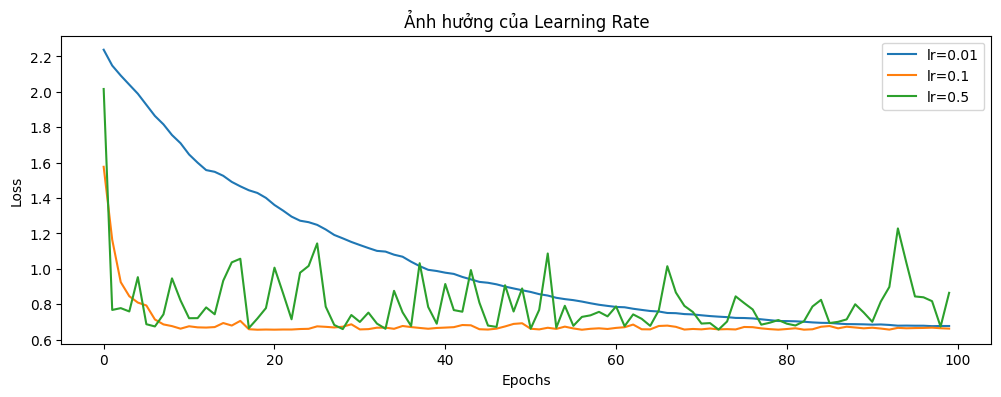

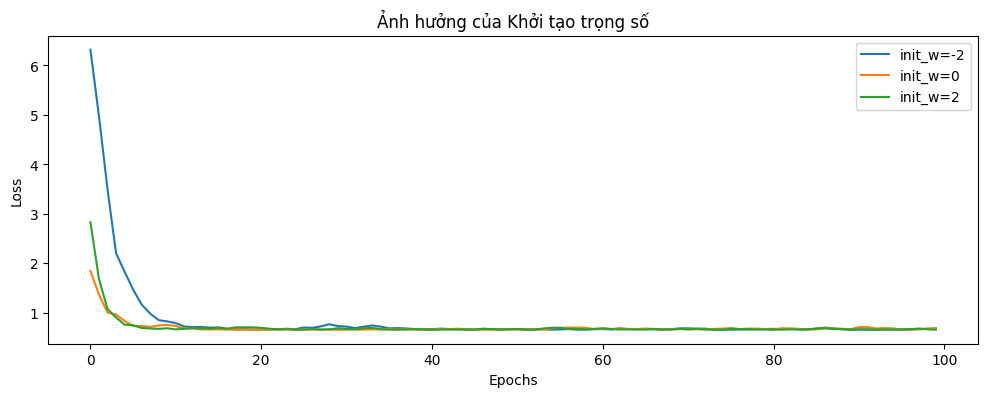

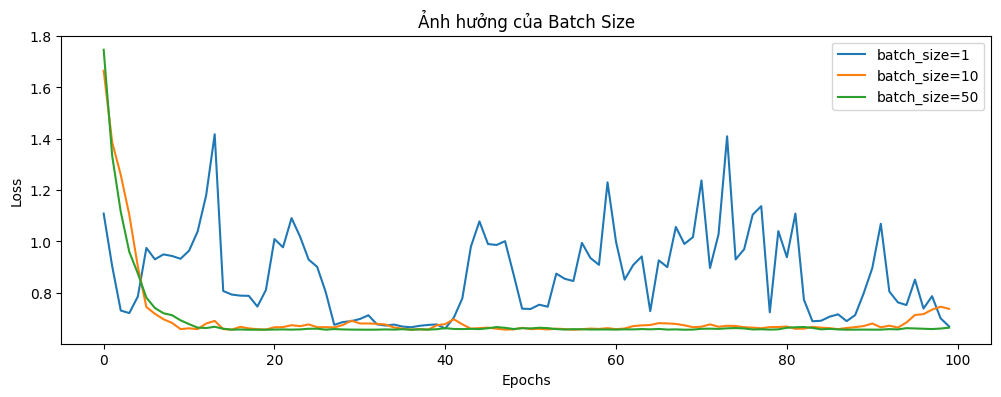

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Load dữ liệu thực tế
data = load_diabetes()
X = data.data[:, np.newaxis, 2]  # Chọn một đặc trưng để đơn giản hóa
Y = data.target.reshape(-1, 1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = scaler.fit_transform(Y)

# Hàm dự đoán
def predict(X, w, b):
    return X @ w + b

# Hàm mất mát (MSE)
def loss_function(X, Y, w, b):
    return np.mean((predict(X, w, b) - Y) ** 2)

# Gradient Descent
def gradient_descent(X, Y, lr, batch_size, init_w, init_b, epochs=100):
    w, b = init_w.astype(np.float64), init_b.astype(np.float64)

    history = []
    
    for _ in range(epochs):
        indices = np.random.choice(len(X), batch_size, replace=False)
        X_batch, Y_batch = X[indices], Y[indices]
        
        grad_w = -2 * X_batch.T @ (Y_batch - predict(X_batch, w, b)) / batch_size
        grad_b = -2 * np.mean(Y_batch - predict(X_batch, w, b))
        
        w -= lr * grad_w
        b -= lr * grad_b
        history.append(loss_function(X, Y, w, b))
    
    return history

# Khởi tạo tham số
global_init_w = np.random.randn(1, 1)
global_init_b = np.random.randn(1)

# Thử nghiệm với các tham số khác nhau
learning_rates = [0.01, 0.1, 0.5]  # Ảnh hưởng của hệ số học
init_weights = [-2, 0, 2]  # Ảnh hưởng của khởi tạo
batch_sizes = [1, 10, 50]  # Ảnh hưởng của batch size

plt.figure(figsize=(12, 4))
for lr in learning_rates:
    history = gradient_descent(X, Y, lr, batch_size=10, init_w=global_init_w.copy(), init_b=global_init_b.copy())
    plt.plot(history, label=f'lr={lr}')
plt.title("Ảnh hưởng của Learning Rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for init_w in init_weights:
    history = gradient_descent(X, Y, lr=0.1, batch_size=10, init_w=np.array([[float(init_w)]]), init_b=global_init_b.copy())

    plt.plot(history, label=f'init_w={init_w}')
plt.title("Ảnh hưởng của Khởi tạo trọng số")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
for batch_size in batch_sizes:
    history = gradient_descent(X, Y, lr=0.1, batch_size=batch_size, init_w=global_init_w.copy(), init_b=global_init_b.copy())
    plt.plot(history, label=f'batch_size={batch_size}')
plt.title("Ảnh hưởng của Batch Size")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### *Các tham số quan trọng ảnh hưởng đến quá trình huấn luyện*
#### 1. *Kích thước tập dữ liệu (\( N \))*
- *Ảnh hưởng*:  
  - Tập dữ liệu lớn (\( N \gg 1000 \)) giúp mô hình ổn định hơn nhưng thời gian tính toán lâu.  
  - Tập dữ liệu nhỏ có thể gây *quá khớp (overfitting)* hoặc *dưới khớp (underfitting)*.
- *Điều chỉnh*:  
  - Dùng *k-fold Cross Validation* để chọn kích thước tập dữ liệu phù hợp.  

---

#### 2. *Tốc độ học (Learning Rate )*
- *Ảnh hưởng*:  
  - Nếu quá *lớn*, mô hình có thể *không hội tụ*, nhảy qua lại giữa các giá trị.  
  - Nếu quá *nhỏ*, mô hình học rất *chậm* hoặc rơi vào cực tiểu cục bộ.  
- *Điều chỉnh*:  
  - Thử nghiệm với nhiều giá trị \( \eta \) như \( 0.01, 0.1, 0.001 \).  
  - Dùng *Learning Rate Decay* (giảm tốc độ học theo thời gian).  

---
## Giải thích về `init_w`

`init_w` là trọng số ban đầu của mô hình trong quá trình huấn luyện sử dụng Gradient Descent. Việc khởi tạo `init_w` có thể ảnh hưởng đáng kể đến tốc độ hội tụ và chất lượng của mô hình. Một số lý do quan trọng cho việc khởi tạo `init_w`:

1. **Tránh hội tụ chậm hoặc bẫy cục bộ**: Nếu trọng số ban đầu quá nhỏ hoặc quá lớn, Gradient Descent có thể cập nhật chậm hoặc mắc kẹt trong một điểm tối ưu cục bộ.
2. **Tối ưu hóa tốc độ hội tụ**: Một khởi tạo phù hợp giúp thuật toán giảm thiểu số lần cập nhật cần thiết để đạt được nghiệm tốt.
3. **Ảnh hưởng đến tính ổn định của quá trình học**: Nếu các trọng số được khởi tạo với cùng một giá trị hoặc giá trị không hợp lý, mô hình có thể không học được tốt.





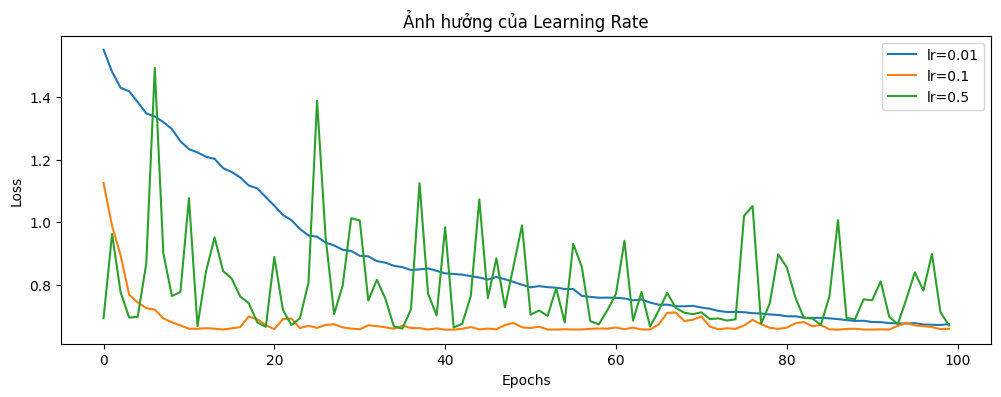

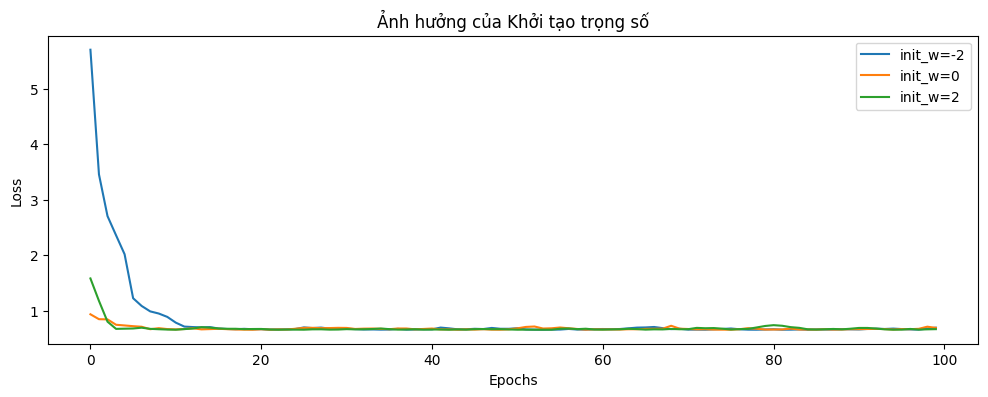

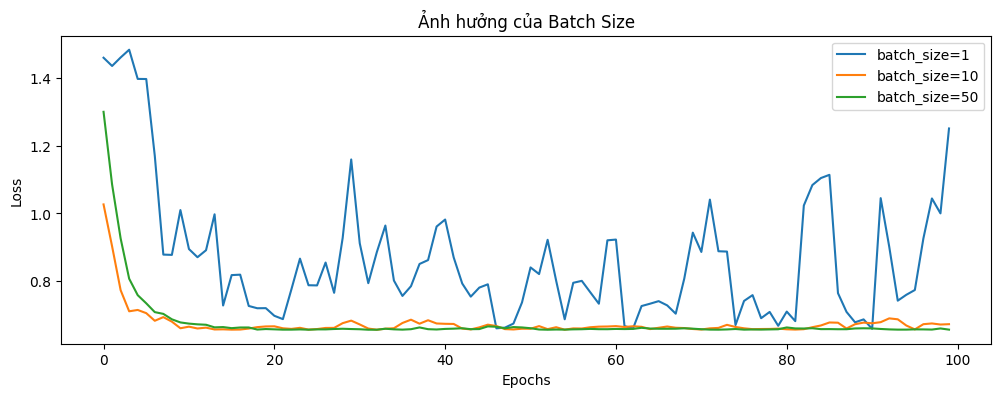

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Load dữ liệu thực tế
data = load_diabetes()
X = data.data[:, np.newaxis, 2]  # Chọn một đặc trưng để đơn giản hóa
Y = data.target.reshape(-1, 1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = scaler.fit_transform(Y)

# Hàm dự đoán
def predict(X, w, b):
    return X @ w + b

# Hàm mất mát (MSE)
def loss_function(X, Y, w, b):
    return np.mean((predict(X, w, b) - Y) ** 2)

# Gradient Descent
def gradient_descent(X, Y, lr, batch_size, init_w, init_b, epochs=100):
    w, b = init_w.astype(np.float64), init_b.astype(np.float64)

    history = []
    
    for _ in range(epochs):
        indices = np.random.choice(len(X), batch_size, replace=False)
        X_batch, Y_batch = X[indices], Y[indices]
        
        grad_w = -2 * X_batch.T @ (Y_batch - predict(X_batch, w, b)) / batch_size
        grad_b = -2 * np.mean(Y_batch - predict(X_batch, w, b))
        
        w -= lr * grad_w
        b -= lr * grad_b
        history.append(loss_function(X, Y, w, b))
    
    return history

# Khởi tạo tham số
global_init_w = np.random.randn(1, 1)
global_init_b = np.random.randn(1)

# Thử nghiệm với các tham số khác nhau
learning_rates = [0.01, 0.1, 0.5]  # Ảnh hưởng của hệ số học
init_weights = [-2, 0, 2]  # Ảnh hưởng của khởi tạo
batch_sizes = [1, 10, 50]  # Ảnh hưởng của batch size

# Plot 1 - Ảnh hưởng của Learning Rate
plt.figure(figsize=(12, 4))
for lr in learning_rates:
    history = gradient_descent(X, Y, lr, batch_size=10, init_w=global_init_w.copy(), init_b=global_init_b.copy())
    plt.plot(history, label=f'lr={lr}')
plt.title("Ảnh hưởng của Learning Rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig('learning_rate_effect.svg', format='svg')
plt.show()

# Plot 2 - Ảnh hưởng của Khởi tạo trọng số
plt.figure(figsize=(12, 4))
for init_w in init_weights:
    history = gradient_descent(X, Y, lr=0.1, batch_size=10, init_w=np.array([[float(init_w)]]), init_b=global_init_b.copy())
    plt.plot(history, label=f'init_w={init_w}')
plt.title("Ảnh hưởng của Khởi tạo trọng số")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig('init_weight_effect.svg', format='svg')
plt.show()

# Plot 3 - Ảnh hưởng của Batch Size
plt.figure(figsize=(12, 4))
for batch_size in batch_sizes:
    history = gradient_descent(X, Y, lr=0.1, batch_size=batch_size, init_w=global_init_w.copy(), init_b=global_init_b.copy())
    plt.plot(history, label=f'batch_size={batch_size}')
plt.title("Ảnh hưởng của Batch Size")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig('batch_size_effect.svg', format='svg')
plt.show()
